In [10]:
import cv2 as cv
import numpy as np
import os
import math
from matplotlib import pyplot as plt

# Question 1


image shape (256, 256)


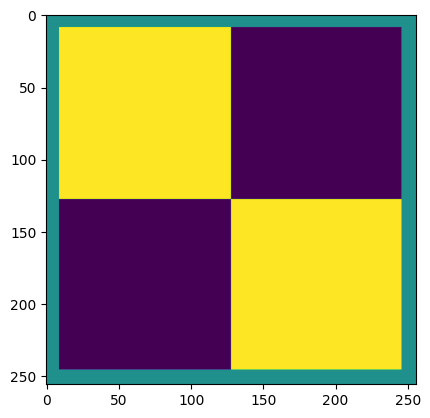

In [11]:
img = cv.imread("input/ps1-input0.png", cv.IMREAD_GRAYSCALE)
print("image shape", img.shape)
plt.imshow(img)
plt.show()

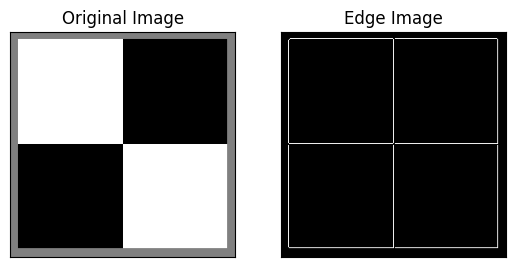

In [12]:
img_edges = cv.Canny(img,20,50)
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

# Hough Transform

In [13]:
img_edges = cv.Canny(img,20,50)
img_edges


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [446]:
from tqdm import tqdm
import pickle

def hough_transform(img, img_edges, rho_jumps=1, theta_jumps=3, max_theta=180):

    max_d = np.sqrt(img.shape[0]**2 + img.shape[1]**2)

    d_values_range = np.arange(-max_d, max_d + rho_jumps, rho_jumps)
    theta_values = np.arange(0, max_theta, theta_jumps)

    coss = np.cos(np.deg2rad(theta_values))
    sins = np.sin(np.deg2rad(theta_values))

    H = np.zeros((len(d_values_range), len(theta_values))) 

    edges_indices = np.argwhere(img_edges > 0)
    print("Going thorugh the edges pixels")
    for edge_index in tqdm(edges_indices):
        y,x = edge_index
        d_values = x * coss + y * sins
        for theta_index, d in enumerate(d_values):
            d_index = np.argmin(np.abs(d_values_range - d))
            H[d_index, theta_index] += 1

    with open("accumulator.pkl", "wb") as file:
        pickle.dump(H, file)
    return H, d_values_range, theta_values



In [119]:
H, rho, theta = hough_transform(img, img_edges,theta_jumps=0.5,)

Going thorugh the edges pixels


100%|██████████| 1406/1406 [00:04<00:00, 311.52it/s]


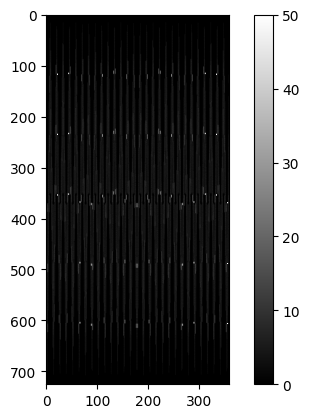

In [123]:
# plt.imshow(H), plt.xticks([]), plt.yticks([])
img12 = H.astype(np.uint8)
plt.imshow(img12, cmap="gray", vmin=0,vmax=50)
plt.colorbar()
plt.show()

In [124]:
def hough_peaks(accumulator, num_peaks=10,  threshold=0, nhood_size=3):
    peaks = []
    H_new = np.copy(accumulator)
    # Iterate until desired number of peaks found
    for i in range(num_peaks):
        # Find maximum peak value
        idx = np.argmax(H_new)
        r, c = np.unravel_index(idx, H_new.shape)
        
        # Check if peak value is above threshold
        if H_new[r, c] >= threshold:
            peaks.append((r, c))
            
            # Suppress the local neighborhood of the peak
            r_min = max(0, r - (nhood_size // 2))
            r_max = min(H_new.shape[0], r + (nhood_size // 2) + 1)
            c_min = max(0, c - (nhood_size // 2))
            c_max = min(H_new.shape[1], c + (nhood_size // 2) + 1)
            
            H_new[r_min:r_max, c_min:c_max] = 0
        
        else:
            break
    
    return np.array(peaks)
    

In [463]:
def hough_lines_draw(img, H, peaks, rho, theta, over_empty_image=False):
    new_img = np.copy(img)
    # new_img = np.copy(img_edges)
    if over_empty_image:
        new_img = np.zeros(img.shape)

    peak_rho_indices = peaks[:,0]
    peak_theta_indices = peaks[:,1]

    peak_rho = rho[peak_rho_indices]
    peak_theta = theta[peak_theta_indices]

    x1 = peak_rho * np.cos(np.deg2rad(peak_theta))
    y1 = peak_rho * np.sin(np.deg2rad(peak_theta))

    direction = np.array([-x1, y1])
    
    pts2 = np.array([y1,x1]) - 1000 * direction
    pts1 = np.array([y1,x1]) + 1000 * direction

    for i in range(len(pts1[0])):
        pt1 = np.round([pts1[0,i], pts1[1,i]]).astype(np.int64)
        pt2 = np.round([pts2[0,i], pts2[1,i]]).astype(np.int64)
        new_img = cv.line(new_img, pt1,pt2,color=[255,0,0], thickness=1)
    

    plt.imshow(new_img)

# peaks= hough_peaks(H, num_peaks=109,threshold=0, nhood_size=10)
# hough_lines_draw(img_smooth, H, peaks, rho, theta)


In [452]:
img = cv.imread("input/ps1-input0.png", cv.IMREAD_GRAYSCALE)
img_edges = cv.Canny(img,20,50)
H, rho, theta = hough_transform(img, img_edges, rho_jumps=0.5 ,theta_jumps=0.5,)

Going thorugh the edges pixels


100%|██████████| 1406/1406 [00:04<00:00, 297.98it/s]


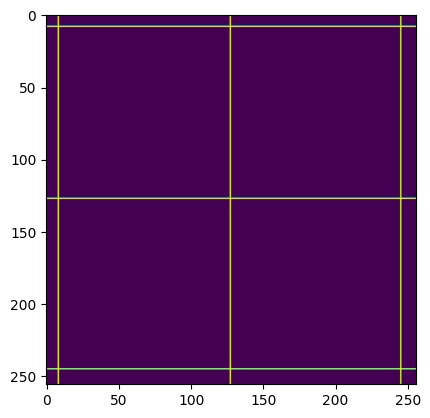

In [453]:

peaks = hough_peaks(H, num_peaks=6, threshold=100, nhood_size=5)
hough_lines_draw(img, H, peaks, rho, theta, over_empty_image=True)

### Now we add noise


[[ 88 118 114 ... 128 155 124]
 [ 87 109 114 ... 117 133 109]
 [102 115 121 ... 121 127 109]
 ...
 [ 64  75  90 ... 113 120 106]
 [ 41  61  80 ... 110 117 105]
 [ 34  59  89 ... 102 109  99]]


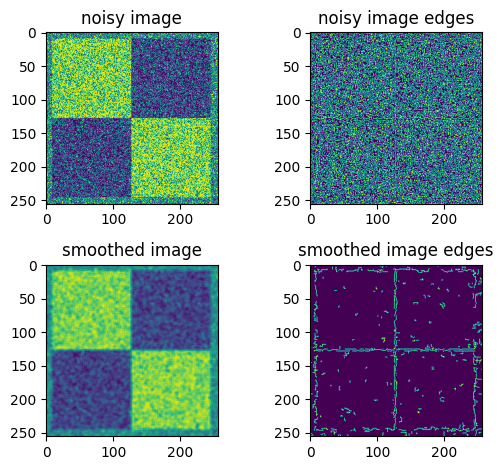

In [454]:
img_with_noise = cv.imread("input/ps1-input0-noise.png", cv.IMREAD_GRAYSCALE)
plt.subplot(221)
plt.title("noisy image")
plt.imshow(img_with_noise)
img_with_noise_edges = cv.Canny(img_with_noise, 220,150)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_with_noise_edges)


# kernel = cv.getGaussianKernel(49, 5).reshape(7,7)
# kernel = np.ones((5,5),np.float32)/25
# print(kernel)

# img_smooth = cv.filter2D(img_with_noise,-1,kernel)
img_smooth = cv.GaussianBlur(img_with_noise, (5,5), 20)
print(img_smooth)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth)
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 220,150)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges)
plt.tight_layout()

plt.show()

In [455]:
H, rho, theta = hough_transform(img_smooth, img_smooth_edges, rho_jumps=0.5 ,theta_jumps=0.5,)


Going thorugh the edges pixels


100%|██████████| 2733/2733 [00:08<00:00, 322.07it/s]


#### The lines of the noisy image

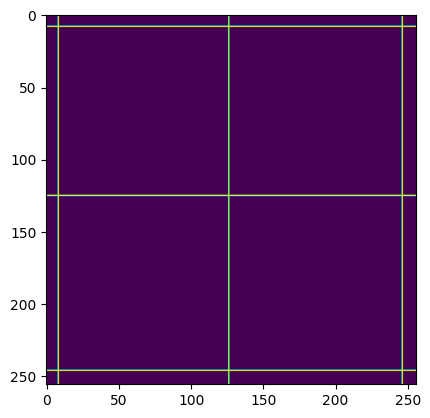

In [456]:

peaks = hough_peaks(H, num_peaks=100, threshold=70, nhood_size=20)
hough_lines_draw(img_smooth, H, peaks, rho, theta, over_empty_image=True)

### 4. Circles and stuff

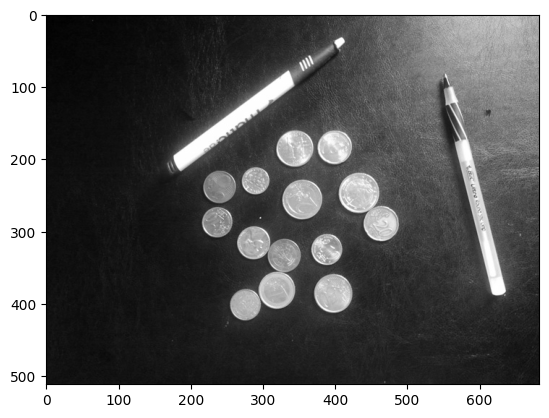

In [458]:
img = cv.imread("input/ps1-input1.png", cv.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")

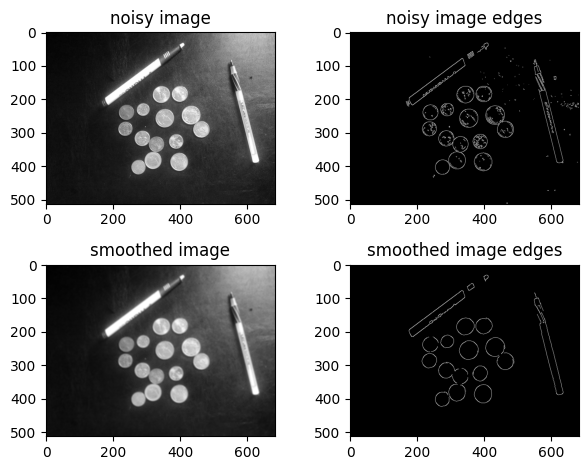

In [460]:
plt.subplot(221)
plt.title("noisy image")
plt.imshow(img, cmap="gray")

img_edges = cv.Canny(img, 220,150)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_edges, cmap="gray")

img_smooth = cv.GaussianBlur(img, (5,5), 20)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth, cmap="gray")
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 200,150)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges, cmap="gray")
plt.tight_layout()

plt.show()


In [474]:
H, rho, theta = hough_transform(img_smooth, img_smooth_edges, rho_jumps=0.5, theta_jumps=0.5)

Going thorugh the edges pixels


100%|██████████| 3836/3836 [00:14<00:00, 268.16it/s]


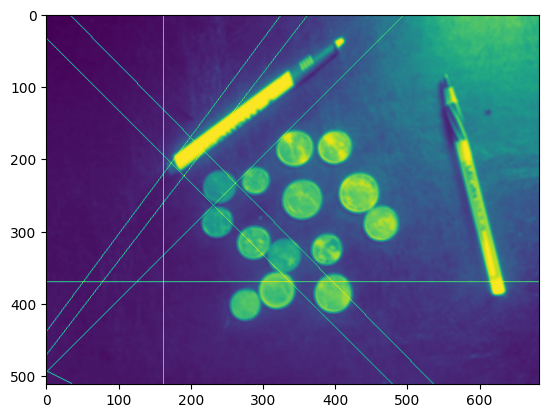

In [476]:
peaks= hough_peaks(H, num_peaks=10,threshold=0, nhood_size=100)
hough_lines_draw(img_smooth, H, peaks, rho, theta)


In [ ]:
def hough_transform_circles(img, img_edges, rho_jumps=1, theta_jumps=3, max_theta=180):

    max_d = np.sqrt(img.shape[0]**2 + img.shape[1]**2)

    d_values_range = np.arange(-max_d, max_d + rho_jumps, rho_jumps)
    theta_values = np.arange(0, max_theta, theta_jumps)

    coss = np.cos(theta_values)
    sins = np.sin(theta_values)

    H = np.zeros((len(d_values_range), len(theta_values))) 

    edges_indices = np.argwhere(img_edges > 0)
    print("Going thorugh the edges pixels")
    for edge_index in tqdm(edges_indices):
        y,x = edge_index
        d_values = x * coss + y * sins
        for theta_index, d in enumerate(d_values):
            d_index = np.argmin(np.abs(d_values_range - d))
            H[d_index, theta_index] += 1

    with open("accumulator.pkl", "wb") as file:
        pickle.dump(H, file)
    return H, d_values_range, theta_values